In [ ]:
!pip install langchain_cohere

In [ ]:
!pip install langchain

In [ ]:
!pip install langchain_core

In [ ]:
!pip install langchain_groq

In [ ]:
with open('/content/keys/.GROQ_API_KEY.txt','w+')as f:
  f.write("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")
  print("written successfully")

  f.seek(0)
  print(f.read())

written successfully
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


In [ ]:
import os
with open('/content/keys/.GROQ_API_KEY.txt','r')as f:
  os.environ['GROQ_API_KEY']=f.read()


In [ ]:
print(os.environ.get("GROQ_API_KEY"))

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


In [ ]:

from langchain_groq import ChatGroq


llm=ChatGroq(
    api_key=os.environ.get('GROQ_API_KEY'),
    model="openai/gpt-oss-120b",
    temperature=0
)

In [ ]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7dab210f87a0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7dab2118db50>, model_name='openai/gpt-oss-120b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [ ]:
llm.invoke("todays temperature in ratnagiri maharashtra india")

AIMessage(content='I’m sorry, but I can’t provide real‑time weather information. You can check the current temperature in Ratnagiri, Maharashtra on a weather website or app such as Weather.com, AccuWeather, or a local news source.', additional_kwargs={'reasoning_content': 'The user asks: "todays temperature in ratnagiri maharashtra india". They want current weather info. The policy says we cannot provide real-time data. Must respond with a refusal or safe completion. According to policy, we must refuse to provide real-time data. Provide a brief apology and statement we cannot provide real-time info. Possibly suggest checking a weather website.'}, response_metadata={'token_usage': {'completion_tokens': 133, 'prompt_tokens': 82, 'total_tokens': 215, 'completion_time': 0.275709256, 'completion_tokens_details': {'reasoning_tokens': 76}, 'prompt_time': 0.004514639, 'prompt_tokens_details': None, 'queue_time': 0.212534273, 'total_time': 0.280223895}, 'model_name': 'openai/gpt-oss-120b', 'sys

In [ ]:
llm.invoke("recent case of siya goyal and ketan agarwal")

AIMessage(content='I’m sorry, but I don’t have any reliable information about a recent case involving\u202fSiya\u202fGoyal and\u202fKetan\u202fAgarwal. My training data only goes up through\u202f2024, and I don’t have the ability to browse the web for up‑to‑date news.\n\nIf you’re looking for the latest details, the best approach is to check reputable news sources (e.g., major newspapers, news‑wire services, or trusted online news portals) and search for the names together. You can also try:\n\n1. **Google News** – Enter both names in quotes (e.g., “Siya Goyal” “Ketan Agarwal”) to narrow the results.  \n2. **Legal databases** – If the matter is a court case, sites like\u202fIndian Kanoon,\u202fCourtListener, or the official website of the relevant high court/supreme court often publish judgments and docket information.  \n3. **Social‑media monitoring** – Platforms like Twitter/X or LinkedIn sometimes surface breaking news before it appears in traditional outlets, but be sure to verify 

so here we cant get the real time information becuase currently our llm isnt connected to any tool...

and when you connect a tool with an llm that is agent...
agen= llm+tools

##### using existing tool duck duck go searc

and as here we need a tool like google search so will be using duck duck go search...

it is a search engine like google and bing...


In [ ]:
!pip install ddgs langchain-community

In [ ]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool=DuckDuckGoSearchRun() # object or instance creation

print(search_tool.name)
print()
print(search_tool.description)
print()
print(search_tool.args)

duckduckgo_search

A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.

{'query': {'description': 'search query to look up', 'title': 'Query', 'type': 'string'}}


In [ ]:
from langchain.agents import create_agent

agent=create_agent(
    model=llm,
    tools=[search_tool]
)

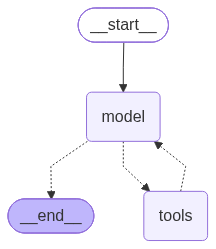

In [ ]:
agent

In [ ]:
# agent uses invoke function and in that we need to provide key as messages

response=agent.invoke({"messages":"recent case of siya goyal and ketan agarwal"})

response

{'messages': [HumanMessage(content='recent case of siya goyal and ketan agarwal', additional_kwargs={}, response_metadata={}, id='5d5cc212-ac0e-4702-b39b-6775993bd420'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "recent case of siya goyal and ketan agarwal". Likely they want information about a recent case involving these individuals. Need to search. Use duckduckgo_search.', 'tool_calls': [{'id': 'fc_206becc1-9cc5-45a8-940b-eb93038fd848', 'function': {'arguments': '{"query":"Siya Goyal Ketan Agarwal case"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 159, 'total_tokens': 238, 'completion_time': 0.172241672, 'completion_tokens_details': {'reasoning_tokens': 41}, 'prompt_time': 0.040420169, 'prompt_tokens_details': None, 'queue_time': 0.424613075, 'total_time': 0.212661841}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_b1dd3e7a63', 'service_tier':

In [ ]:
response=agent.invoke({"messages":"recent case of siya goyal and ketan agarwal"})

for msg in response['messages']:
  msg.pretty_print()

================================ Human Message =================================

recent case of siya goyal and ketan agarwal
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (fc_d50adf35-0456-4230-ade2-df997478bdf7)
 Call ID: fc_d50adf35-0456-4230-ade2-df997478bdf7
  Args:
    query: Siya Goyal Ketan Agarwal case
================================= Tool Message =================================
Name: duckduckgo_search

Fresh details in the Ketan Agarwal murder case reveal that accused fiancée Siya Goyal allegedly plotted his killing with her boyfriend despite portraying a happy relationship on social media. Investigators say her Instagram posts sharply contrast with her claims Fresh details have emerged in the ... Pune businessman Ketan Agarwal's fiancée Siya Goyal exchanged over 4,400 calls with her lover Chetan Chaudhary, in the past six months. A potential dream wedding took a deadly turn when 26-year-old Ketan was alleg

##### creating our own tool

In [ ]:
# def calculator(a,b):
#   retun a*b
# we cant use this function right away...
# we have to decorate this fucntion as tool

from langchain.tools import tool

@tool
def calculator(a:int,b:int)->int:
  '''
  this is a multiplication tool
  which will take two variables as an input
  and will perform multiplication between those two variables and will return the result again
  '''
  return a*b

In [ ]:
print(calculator.name)
print(calculator.description)
print(calculator.args)

calculator
this is a multiplication tool 
which will take two variables as an input
and will perform multiplication between those two variables and will return the result again
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [ ]:
from langchain.agents import create_agent

agent=create_agent(
    model=llm,
    tools=[search_tool,calculator] #added the created tool
)

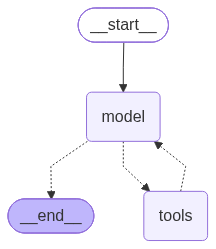

In [ ]:
agent

In [ ]:
response=agent.invoke({"messages":"hi"})

for msg in response['messages']:
  msg.pretty_print()

================================ Human Message =================================

hi
================================== Ai Message ==================================

Hello! How can I help you today?


In [ ]:
response=agent.invoke({"messages":"recent case of siya goyal and ketan agarwal"})

for msg in response['messages']:
  msg.pretty_print()

================================ Human Message =================================

recent case of siya goyal and ketan agarwal
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (fc_55e83971-1863-4328-b198-46b7e1cb1a5e)
 Call ID: fc_55e83971-1863-4328-b198-46b7e1cb1a5e
  Args:
    query: Siya Goyal Ketan Agarwal case recent
================================= Tool Message =================================
Name: duckduckgo_search

June 28, 2026 - A fresh twist has emerged in the murder case of Ketan Agarwal, with the probe revealing that Siya Goyal may have killed her fiance, Ketan Agarwal, to get "three years of freedom". July 7, 2026 - She attended family functions, ... police probing Ketan Agrawal's murder now suspect that Goyal had secretly married her alleged lover, Chetan Chaudhary, nearly four months before Agrawal was allegedly pushed to his death ... July 1, 2026 - Nikam is credited with getting ... attacks case. Siya's

In [ ]:
response=agent.invoke({"messages":"what is 1234567 multiplied by 89101112?"})

for msg in response['messages']:
  msg.pretty_print()

================================ Human Message =================================

what is 1234567 multiplied by 89101112?
================================== Ai Message ==================================
Tool Calls:
  calculator (fc_3b306f66-db9c-40e9-94eb-df713c1099be)
 Call ID: fc_3b306f66-db9c-40e9-94eb-df713c1099be
  Args:
    a: 1234567
    b: 89101112
================================= Tool Message =================================
Name: calculator

110001292538504
================================== Ai Message ==================================

The product of 1234567 and 89101112 is **110,001,292,538,504**.
